<a href="https://colab.research.google.com/github/dsouzabrandon02-ops/CSL701-14_Machine-Learning-Lab/blob/main/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Brandon B Dsouza

Batch : cs1


Roll Number : cs14



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("/content/data.csv")

# Display first 5 rows
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape: (569, 33)

Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
co

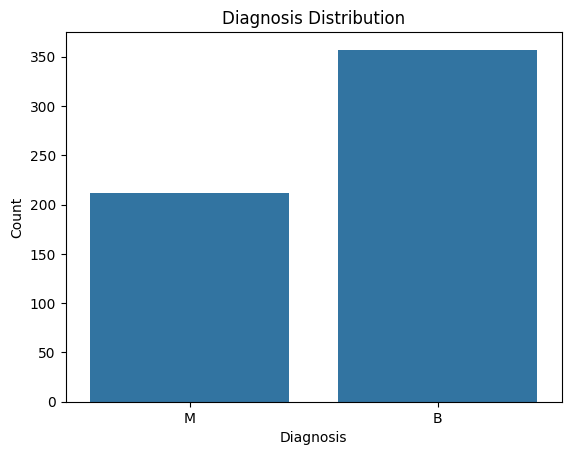

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Diagnosis distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# Plot class distribution
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Drop unnecessary columns
df = df.drop(["id", "Unnamed: 32"], axis=1)

# Convert diagnosis into numerical values
# M = 1 and B = 0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Separate features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns)

print("\nTarget Values:")
print(y.value_counts())

Feature Shape: (569, 30)
Target Shape: (569,)

Features:
Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Target Values:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Create StandardScaler object
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

print("Standardized Data Shape:", X_scaled.shape)

# Display first 5 rows
print("\nFirst 5 rows after standardization:")
print(X_scaled[:5])

Standardized Data Shape: (569, 30)

First 5 rows after standardization:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Create PCA object with 2 components
pca = PCA(n_components=2)

# Transform standardized data
X_pca = pca.fit_transform(X_scaled)

print("Original Data Shape:", X_scaled.shape)
print("PCA Data Shape:", X_pca.shape)

# Create DataFrame for PCA data
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Add diagnosis
pca_df["Diagnosis"] = y.values

print("\nFirst 5 PCA rows:")
print(pca_df.head())

Original Data Shape: (569, 30)
PCA Data Shape: (569, 2)

First 5 PCA rows:
        PC1        PC2  Diagnosis
0  9.192837   1.948583          1
1  2.387802  -3.768172          1
2  5.733896  -1.075174          1
3  7.122953  10.275589          1
4  3.935302  -1.948072          1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative variance retained by PC1 and PC2:",
      cumulative_variance[-1])

# Convert to percentage
print("\nPC1 Variance: {:.2f}%".format(explained_variance[0] * 100))
print("PC2 Variance: {:.2f}%".format(explained_variance[1] * 100))
print("Total Variance: {:.2f}%".format(cumulative_variance[-1] * 100))

Variance explained by PC1: 0.44272025607526366
Variance explained by PC2: 0.18971182044033078

Cumulative variance retained by PC1 and PC2: 0.6324320765155944

PC1 Variance: 44.27%
PC2 Variance: 18.97%
Total Variance: 63.24%


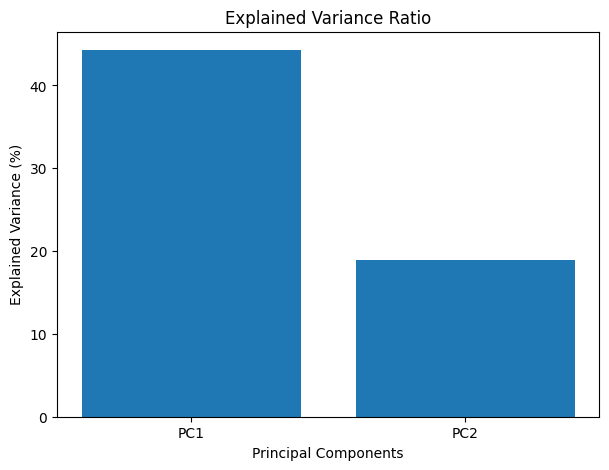

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance * 100
)

plt.ylabel("Explained Variance (%)")
plt.xlabel("Principal Components")
plt.title("Explained Variance Ratio")

plt.show()

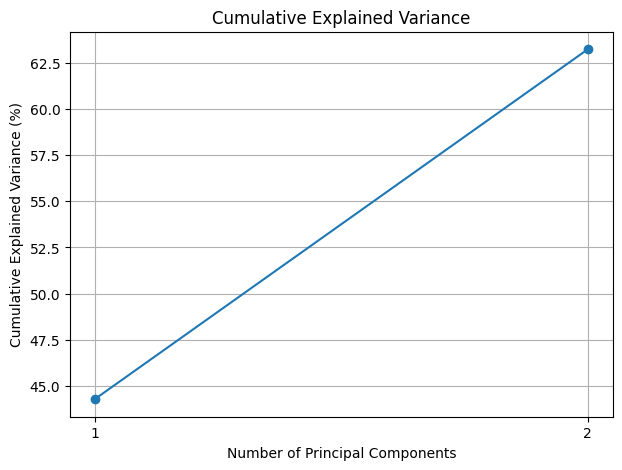

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 3),
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.xticks([1, 2])
plt.grid()

plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

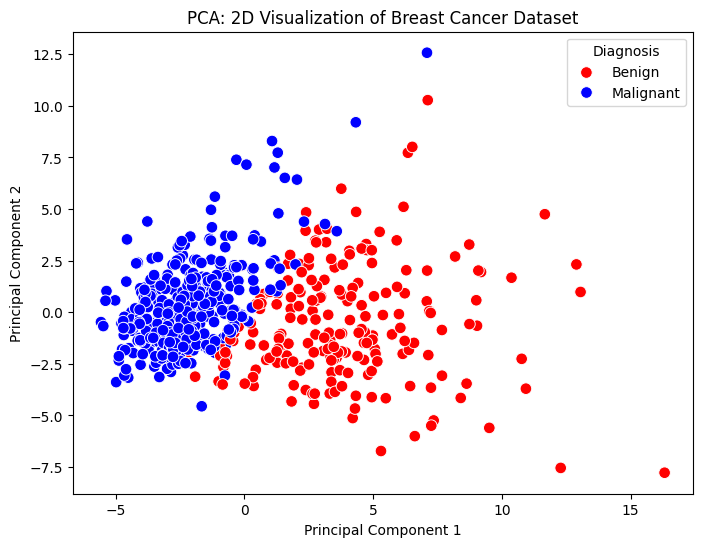

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    data=pca_df,
    palette=["blue", "red"],
    s=70
)

plt.title("PCA: 2D Visualization of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)

plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Split original standardized data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_raw = LogisticRegression(max_iter=1000)

# Train model
logistic_raw.fit(X_train, y_train)

# Predict
y_pred_raw = logistic_raw.predict(X_test)

# Accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression Accuracy before PCA:",
      accuracy_raw)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"]
))

Logistic Regression Accuracy before PCA: 0.9649122807017544

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Split PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_pca = LogisticRegression(max_iter=1000)

# Train model
logistic_pca.fit(X_train_pca, y_train_pca)

# Predict
y_pred_pca = logistic_pca.predict(X_test_pca)

# Accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("Logistic Regression Accuracy after PCA:",
      accuracy_pca)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report:")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

Logistic Regression Accuracy after PCA: 0.9385964912280702

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
# Accuracy comparison
print("========================================")
print("       MODEL PERFORMANCE COMPARISON")
print("========================================")

print("\nAccuracy Before PCA (30 Features):",
      accuracy_raw)

print("Accuracy After PCA (2 Features):",
      accuracy_pca)

print("\nAccuracy Before PCA: {:.2f}%".format(
    accuracy_raw * 100
))

print("Accuracy After PCA: {:.2f}%".format(
    accuracy_pca * 100
))

       MODEL PERFORMANCE COMPARISON

Accuracy Before PCA (30 Features): 0.9649122807017544
Accuracy After PCA (2 Features): 0.9385964912280702

Accuracy Before PCA: 96.49%
Accuracy After PCA: 93.86%


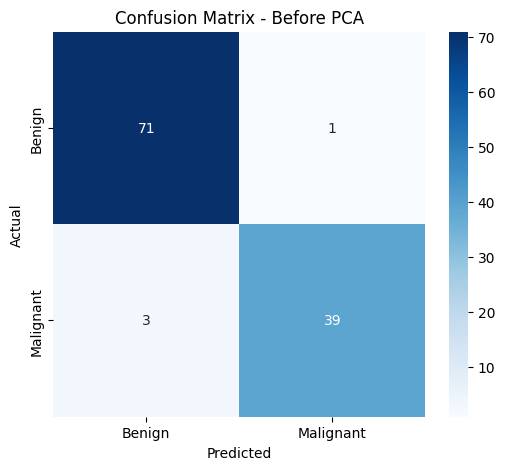

In [ ]:
# Confusion Matrix - Before PCA
cm_raw = confusion_matrix(y_test, y_pred_raw)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix - Before PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

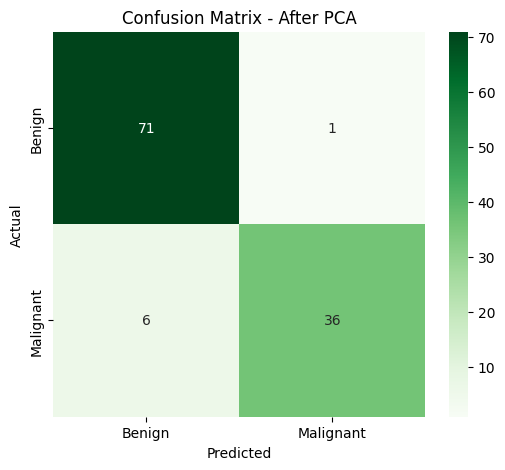

In [ ]:
# Confusion Matrix - After PCA
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Confusion Matrix - After PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print("========== BEFORE PCA ==========")

print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"]
))

print("========== AFTER PCA ==========")

print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

========== BEFORE PCA ==========
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

========== AFTER PCA ==========
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [ ]:
# Generate performance comparison table

report_raw = classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"],
    output_dict=True
)

report_pca = classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"],
    output_dict=True
)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],

    "Before PCA (30 Features)": [
        accuracy_raw,
        report_raw["weighted avg"]["precision"],
        report_raw["weighted avg"]["recall"],
        report_raw["weighted avg"]["f1-score"]
    ],

    "After PCA (2 Features)": [
        accuracy_pca,
        report_pca["weighted avg"]["precision"],
        report_pca["weighted avg"]["recall"],
        report_pca["weighted avg"]["f1-score"]
    ]
})

print(comparison)

      Metric  Before PCA (30 Features)  After PCA (2 Features)
0   Accuracy                  0.964912                0.938596
1  Precision                  0.965185                0.940829
2     Recall                  0.964912                0.938596
3   F1-Score                  0.964725                0.937684


In [ ]:
comparison_percentage = comparison.copy()

comparison_percentage[
    ["Before PCA (30 Features)", "After PCA (2 Features)"]
] *= 100

print(comparison_percentage.round(2))

      Metric  Before PCA (30 Features)  After PCA (2 Features)
0   Accuracy                     96.49                   93.86
1  Precision                     96.52                   94.08
2     Recall                     96.49                   93.86
3   F1-Score                     96.47                   93.77


# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.